# Nearly Free Electron 2


Let the potential be

$V(x) = Acos(\pi a/x) + \frac{A}{2}cos(2\pi x/a) + \frac{A}{3}cos(3\pi x/a)$

with $A=3eV$.
1. Plot the band structure in the first and second BZ for at least 5 bands.
2. Plot the corresponding density of states.
3. Converge the band-structure w.r.t the increasing number of Fourier basis used for
expansion of the Bloch states. (In class we mostly wrote it for five plane wave
basis with G from $G_{-2}$ to $G_2$) .
4. Mark the Fermi energy if each unitcell has one valence electrons.
Converge the Fermi energy w.r.t the increasing number unit cell considered in the supercell,
or in other words, finer k mesh.
5. Next add the potential . Plot bandstructure and density of states.
6. Compute total energy per unit cell by simply adding the energy of the occupied states and
dividing it by . Plot the energy per unitcell as a function of A.
Note however that this is of course the most rudimentory and approximate approach to
compute total energy since we are not considering any interaction among the electrons.

In [262]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
from tqdm import tqdm

hbar = 1.0
a = 1.0
G = np.pi/a
A = 3
V1 = A/2
V2 = A/4
V3 = A/6
basis_m = np.arange(-4, 5)

k_vals = np.linspace(-np.pi/a, np.pi/a, 600)

tp = [
    -np.pi/a,
    -np.pi/(2*a),
    0,
    np.pi/(2*a),
    np.pi/a,
]
tl = [
    r"$-\pi/a$",
    r"$-\pi/(2a)$",
    r"$0$",
    r"$\pi/(2a)$",
    r"$\pi/a$",
]

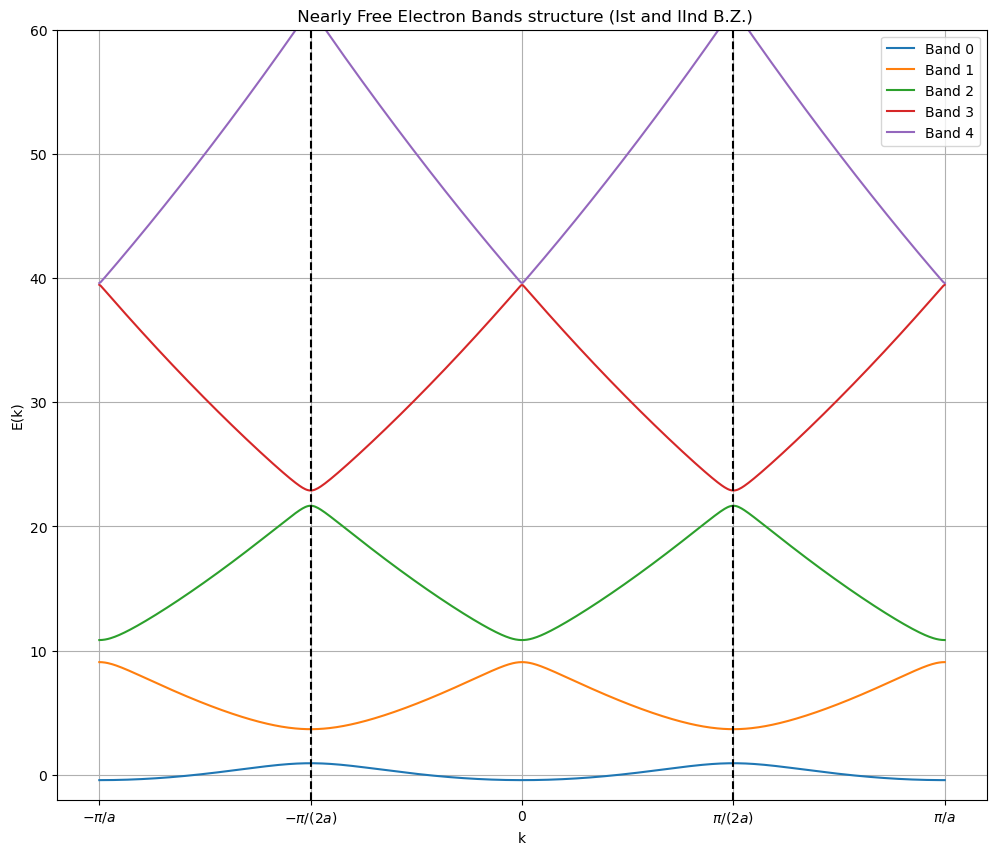

In [263]:
bds = []
for k in k_vals:
    size = len(basis_m)
    H = np.zeros((size, size))
    
    for i, m in enumerate(basis_m):
        H[i, i] = (k + m*G)**2

        if i+1 < size:
            H[i, i+1] = V1
            H[i+1, i] = V1
            
        if i+2 < size:
            H[i, i+2] = V2
            H[i+2, i] = V2

        if i+3 < size:
            H[i, i+3] = V3
            H[i+3, i] = V3
    eigvals = np.linalg.eigvalsh(H)
    bds.append(eigvals)

bds = np.array(bds)

plt.figure(figsize=(12,10))

for n in range(5):
    plt.plot(k_vals, bds[:, n], label=f"Band {n}")
plt.axvline(np.pi/(2*a), linestyle='--', color='black')
plt.axvline(-np.pi/(2*a), linestyle='--', color='black')
plt.xticks(tp, tl)
plt.ylim(-2, 60)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title(" Nearly Free Electron Bands structure (Ist and IInd B.Z.)")
plt.grid(True)
plt.legend()
plt.show()

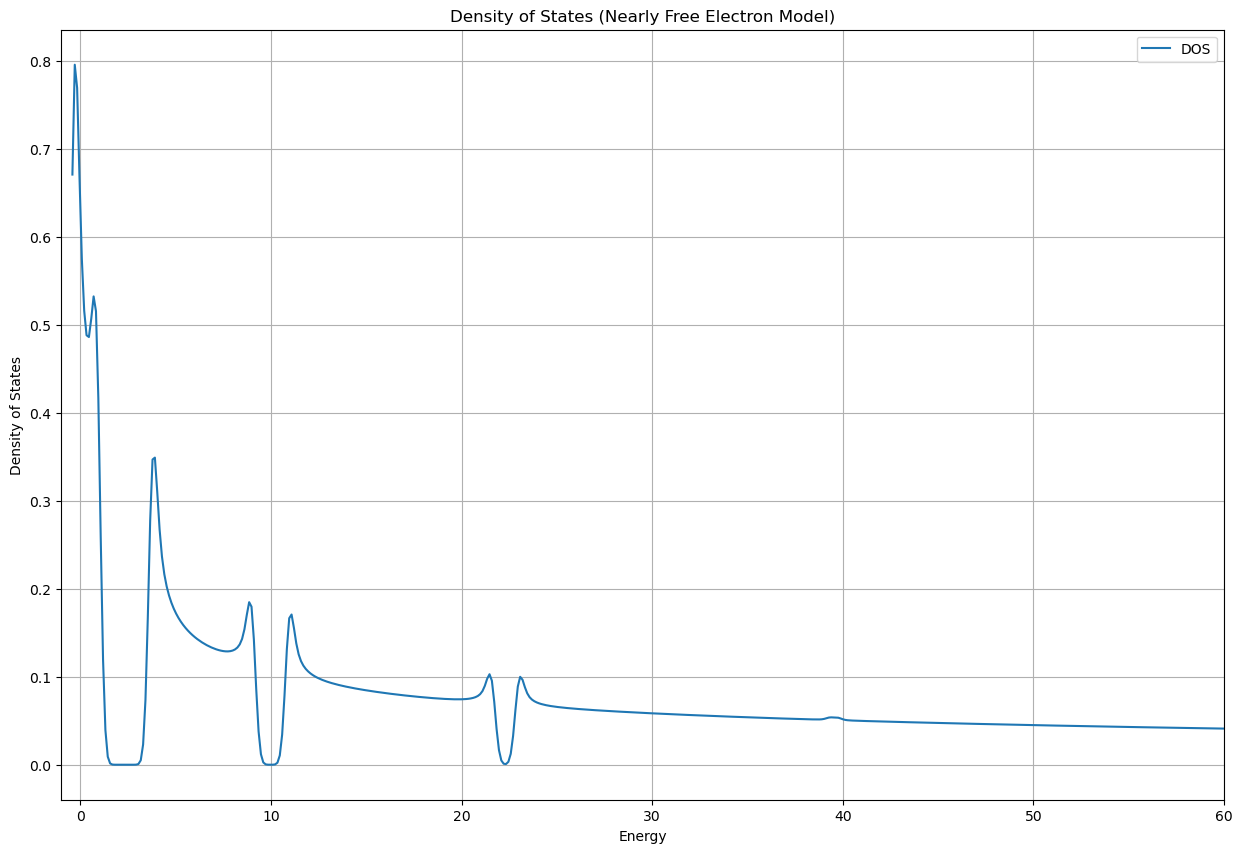

In [264]:
energies = bds.flatten()

E_min = np.min(energies)
E_max = np.max(energies)
E_grid = np.linspace(E_min, E_max, 2000)

# Gaussian smearing (since states are discrete and density of states is a sum of delta functions)
# We perform a Gaussian broadening of each energy level to get a smooth DOS curve
eta = 0.2   
DOS = np.zeros_like(E_grid)
for E in energies:
    DOS += np.exp(-(E_grid - E)**2 / (2*eta**2))

DOS /= (np.sqrt(2*np.pi)*eta)
DOS /= len(k_vals)   

plt.figure(figsize=(15,10))
plt.plot(E_grid, DOS, label="DOS")
plt.ylabel("Density of States")
plt.xlabel("Energy")
plt.xlim((-1,60))
plt.title("Density of States (Nearly Free Electron Model)")
plt.grid(True)
plt.legend()
plt.show()


The dips in the density of states plot represent band gaps. The spikes in density of states before and after the band gaps are due to the slope of the band structure being zero at the band gaps. This increase the number of states in that neighbourhood of energy. Overall, the plot shows a decreasing trend as the overall band structure has a parabolic nature in which the density of states decreases as we go to higher energies.

### Convergence of band structure with increasing Fourier Basis

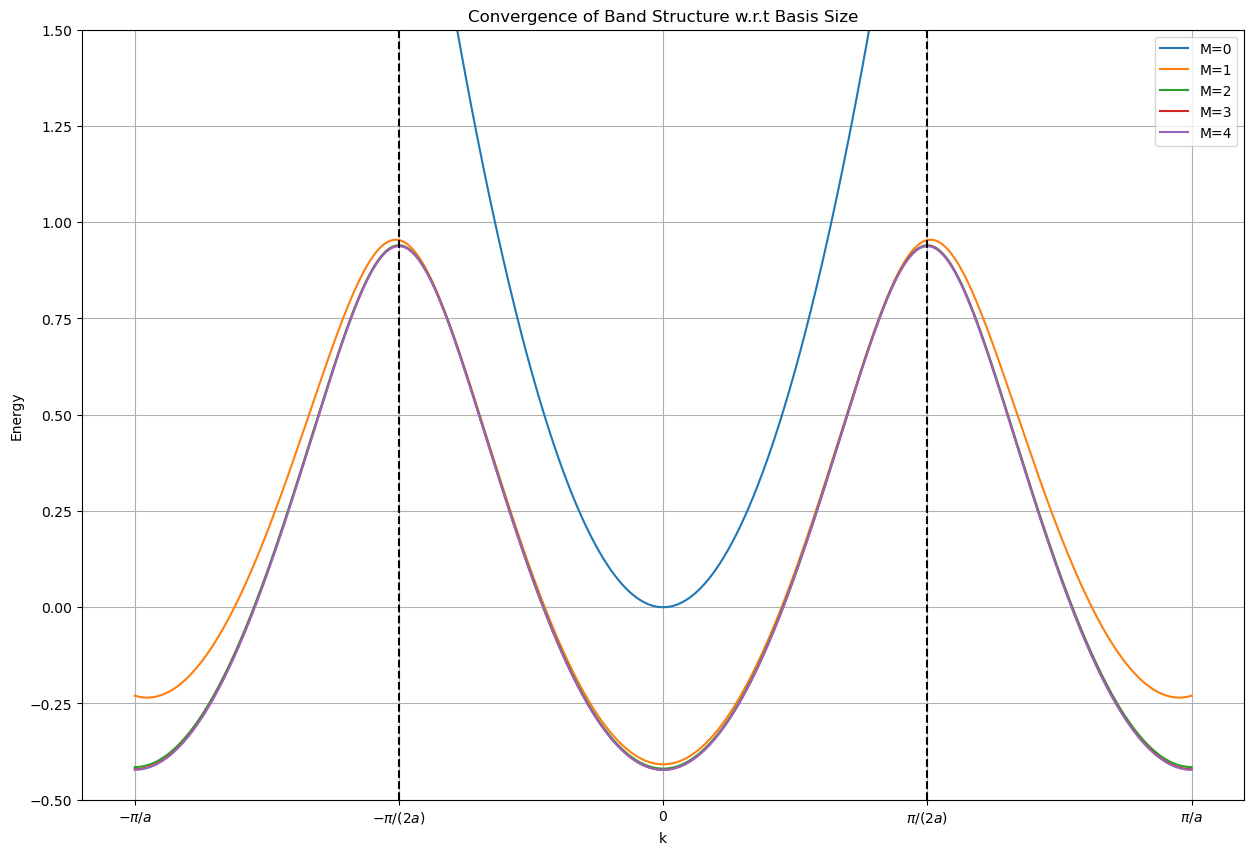

In [265]:
def compute_bands(M, k_vals, A):
    G = np.pi/a
    V1 = A/2
    V2 = A/4
    V3 = A/6
    
    basis_m = np.arange(-M, M+1)
    bands = []
    
    for k in k_vals:
        size = len(basis_m)
        H = np.zeros((size, size))
        
        for i, m in enumerate(basis_m):
            H[i, i] = (k + m*G)**2
            if i+1 < size:
                H[i, i+1] = V1
                H[i+1, i] = V1
    
            if i+2 < size:
                H[i, i+2] = V2
                H[i+2, i] = V2

            if i+3 < size:
                H[i, i+3] = V3
                H[i+3, i] = V3
        
        eigvals = np.linalg.eigvalsh(H)
        bands.append(eigvals)
    
    return np.array(bands)

M_list = [0,1,2,3,4]   
k_vals = np.linspace(-np.pi/a, np.pi/a, 1000)

plt.figure(figsize=(15,10))

for M in M_list:
    bds_M = compute_bands(M, k_vals, A)
    plt.plot(k_vals, bds_M[:,0], label=f"M={M}")

plt.axvline(np.pi/(2*a), linestyle='--', color='black')
plt.axvline(-np.pi/(2*a), linestyle='--', color='black')
plt.xticks(tp, tl)
plt.ylim((-0.5,1.5))
plt.xlabel("k")
plt.ylabel("Energy")
plt.title("Convergence of Band Structure w.r.t Basis Size")
plt.legend()
plt.grid(True)
plt.show()

We plot only the first band for an increasing set of fourier basis $\{G_M\}$. As we increase M, we observe that the band structure converges very quickly with M=4 itself. 


### Fermi Energy Convergence

In [266]:
def compute_bands_kmesh(Nk, M, A):
    bands = []
    k_vals = np.linspace(-np.pi/(2*a), np.pi/(2*a), Nk)
    
    for k in k_vals:
        size = len(basis_m)
        H = np.zeros((size, size))
        for i, m in enumerate(basis_m):
            H[i, i] = (k + m*G)**2

            if i+1 < size:
                H[i, i+1] = V1
                H[i+1, i] = V1
                
            if i+2 < size:
                H[i, i+2] = V2
                H[i+2, i] = V2

            if i+3 < size:
                H[i, i+3] = V3
                H[i+3, i] = V3
        
        eigvals = np.linalg.eigvalsh(H)
        bands.append(eigvals)
    
    return np.array(bands), k_vals

def compute_fermi_energy(Nk, M, A):
    
    bands, k_vals = compute_bands_kmesh(Nk, M, A)
    
    all_energies = bands.flatten()
    all_energies.sort()
    
    Ne = Nk//2   # 1 electron per unit cell (spin degeneracy = 2)
    EF = all_energies[Ne-1]
    
    return EF, bands, k_vals



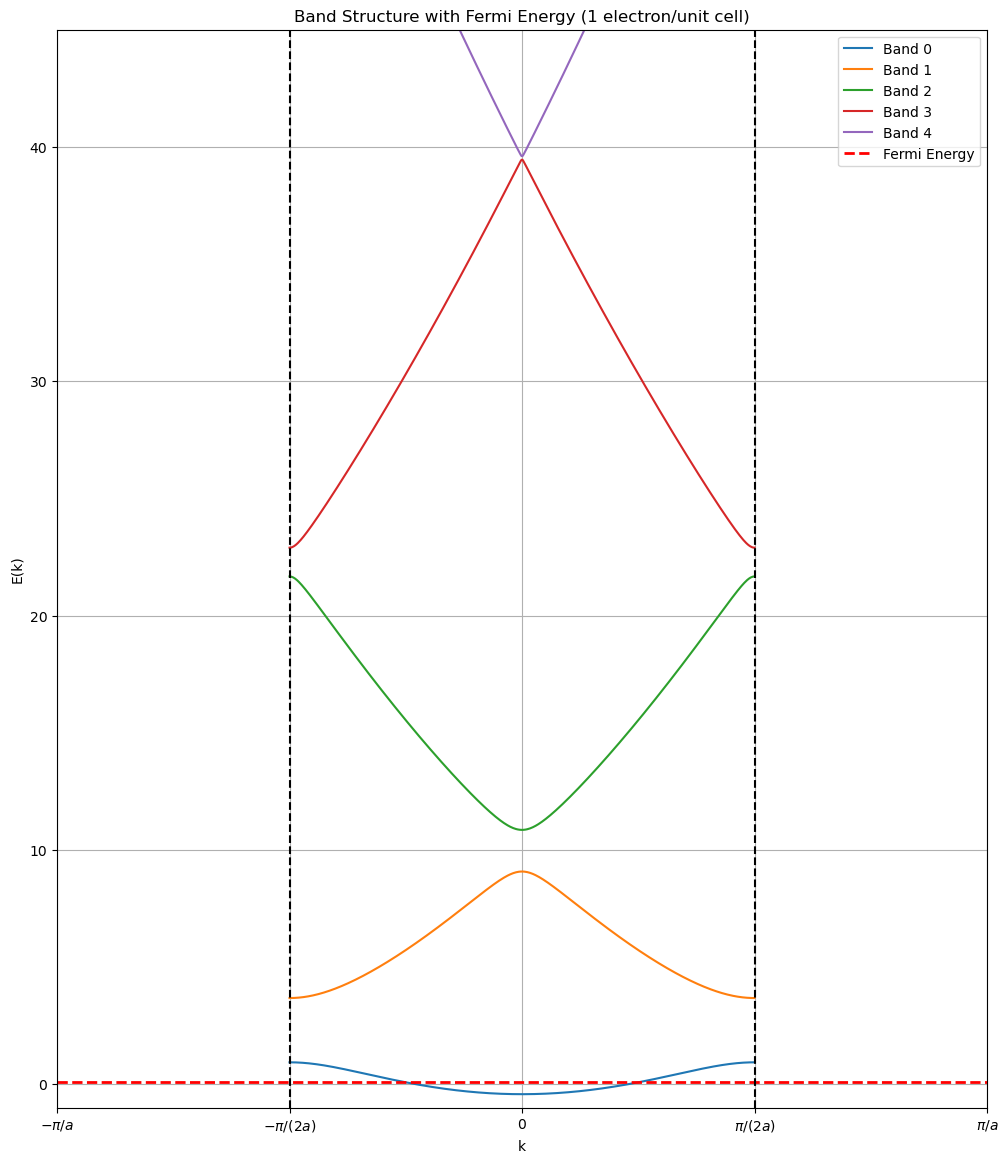

Nk=200, Fermi Energy = 0.0794
Nk=600, Fermi Energy = 0.0826
Nk=1000, Fermi Energy = 0.0832
Nk=2000, Fermi Energy = 0.0837
Nk=5000, Fermi Energy = 0.0840
Nk=8000, Fermi Energy = 0.0841
Nk=15000, Fermi Energy = 0.0841


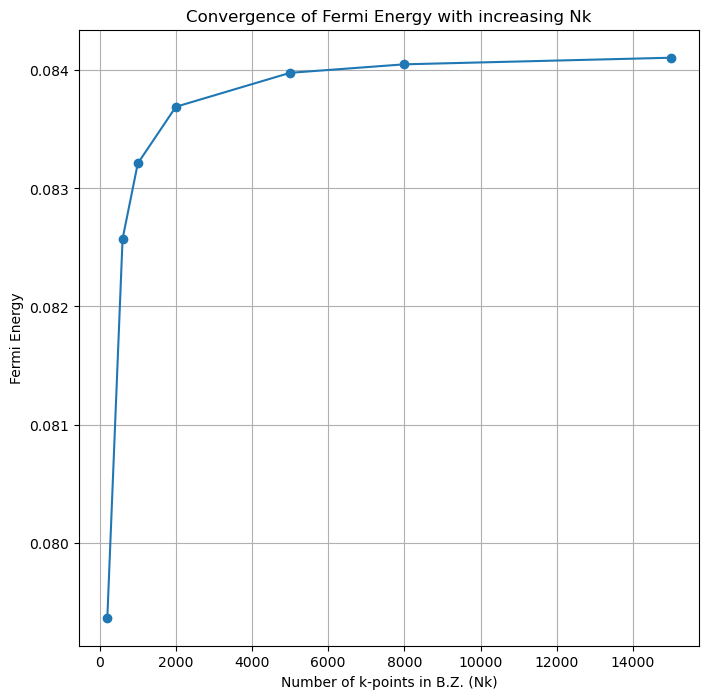

In [267]:
Nk = 500
M = 4
A = 3

EF, bands, k_vals = compute_fermi_energy(Nk, M, A)

plt.figure(figsize=(12,14))

for n in range(5):
    plt.plot(k_vals, bands[:, n], label=f"Band {n}")

plt.axhline(EF, color='red', linestyle='--', linewidth=2, label="Fermi Energy")

plt.axvline(np.pi/(2*a), linestyle='--', color='black')
plt.axvline(-np.pi/(2*a), linestyle='--', color='black')
plt.xticks(tp, tl)
plt.ylim(-1, 45)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title("Band Structure with Fermi Energy (1 electron/unit cell)")
plt.grid(True)
plt.legend()
plt.show()

EF_list = []
Nk_list = [200, 600, 1000, 2000, 5000, 8000,15000]
for Nk in Nk_list:
    EF, bands, k_vals = compute_fermi_energy(Nk, M, A)
    EF_list.append(EF)
    print(f"Nk={Nk}, Fermi Energy = {EF:.4f}")

plt.figure(figsize=(8,8))

plt.plot(Nk_list, EF_list, marker='o')

plt.xlabel("Number of k-points in B.Z. (Nk)")
plt.ylabel("Fermi Energy")
plt.title("Convergence of Fermi Energy with increasing Nk")
plt.grid(True)
plt.show()


We can see that the Fermi Energy converges to 8.3618 as the number of cells in a BVK supercell is increased. 

### Folding of bands


$V(x) = 2Acos(0.5 \pi a/x) + Acos(\pi a/x) + \frac{A}{2}cos(2\pi x/a) + \frac{A}{3}cos(3\pi x/a)$

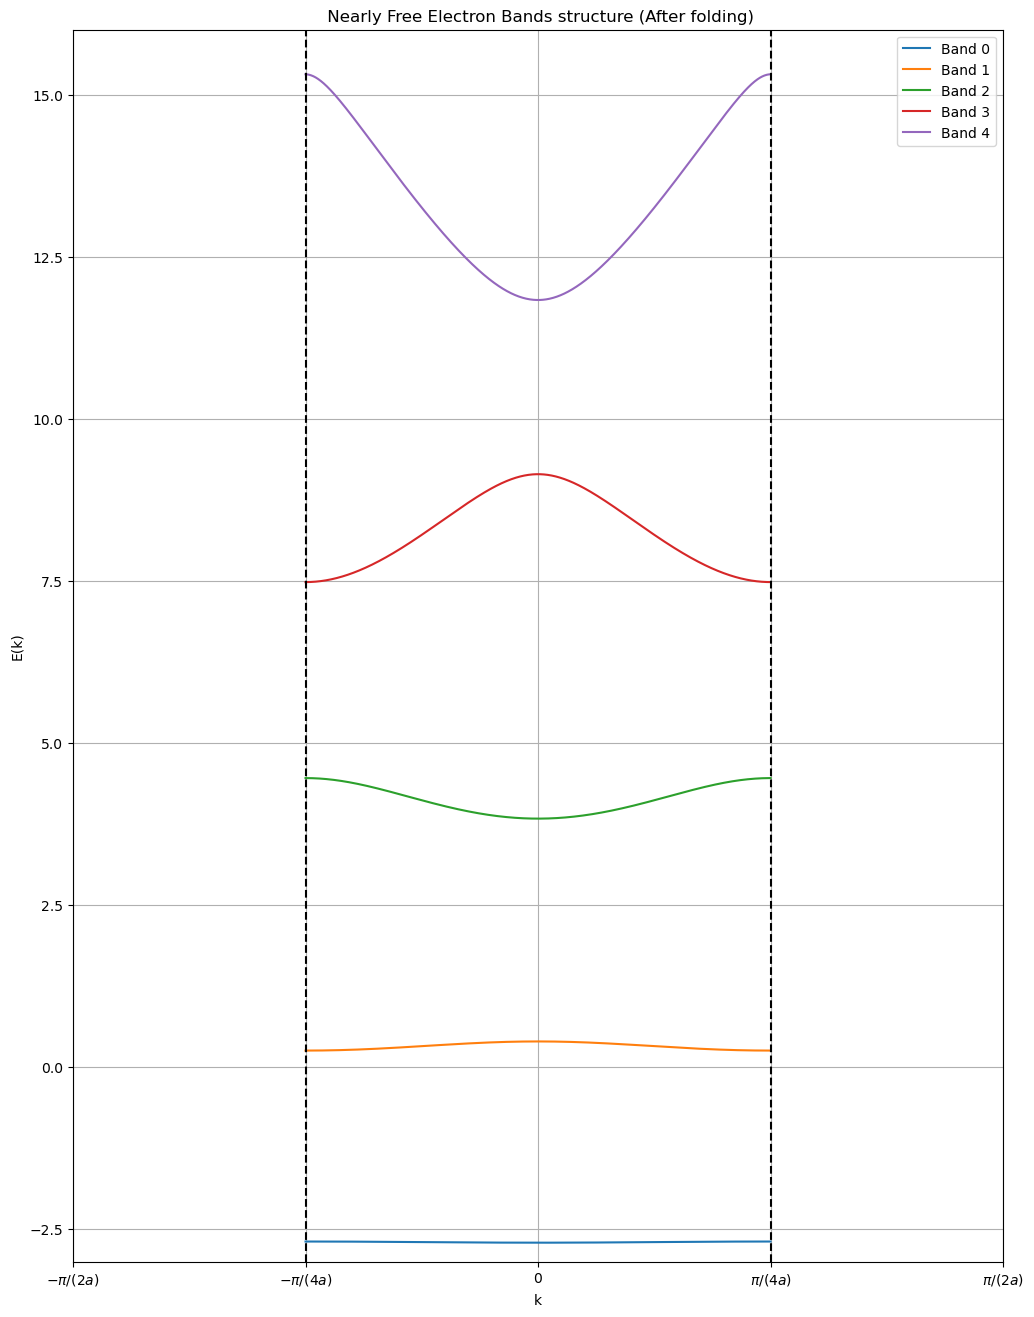

In [268]:
V1 = A
V2 = A/2
V3 = A/4
V4 = A/6

k_vals = np.linspace(-np.pi/(4*a), np.pi/(4*a), 1000)

bds = []
for k in k_vals:
    size = len(basis_m)
    H = np.zeros((size, size))
    
    for i, m in enumerate(basis_m):
        H[i, i] = (k + m*G/2)**2

        if i+1 < size:
            H[i, i+1] = V1
            H[i+1, i] = V1
            
        if i+2 < size:
            H[i, i+2] = V2
            H[i+2, i] = V2

        if i+3 < size:
            H[i, i+3] = V3
            H[i+3, i] = V3

        if i+4 < size:
            H[i, i+4] = V4
            H[i+4, i] = V4
        
        
    eigvals = np.linalg.eigvalsh(H)
    bds.append(eigvals)

tp_new = [
    -np.pi/(2*a),
    -np.pi/(4*a),
    0,
    np.pi/(4*a),
    np.pi/(2*a),
]
tl_new = [
    r"$-\pi/(2a)$",
    r"$-\pi/(4a)$",
    r"$0$",
    r"$\pi/(4a)$",
    r"$\pi/(2a)$",
]

bds = np.array(bds)

plt.figure(figsize=(12,16))

for n in range(5):
    plt.plot(k_vals, bds[:, n], label=f"Band {n}")
plt.axvline(np.pi/(4*a), linestyle='--', color='black')
plt.axvline(-np.pi/(4*a), linestyle='--', color='black')
plt.xticks(tp_new, tl_new)
plt.ylim(-3, 16)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title(" Nearly Free Electron Bands structure (After folding)")
plt.grid(True)
plt.legend()
plt.show()

We observe folding of bands (similar to the previous assignment)

Density of states now:

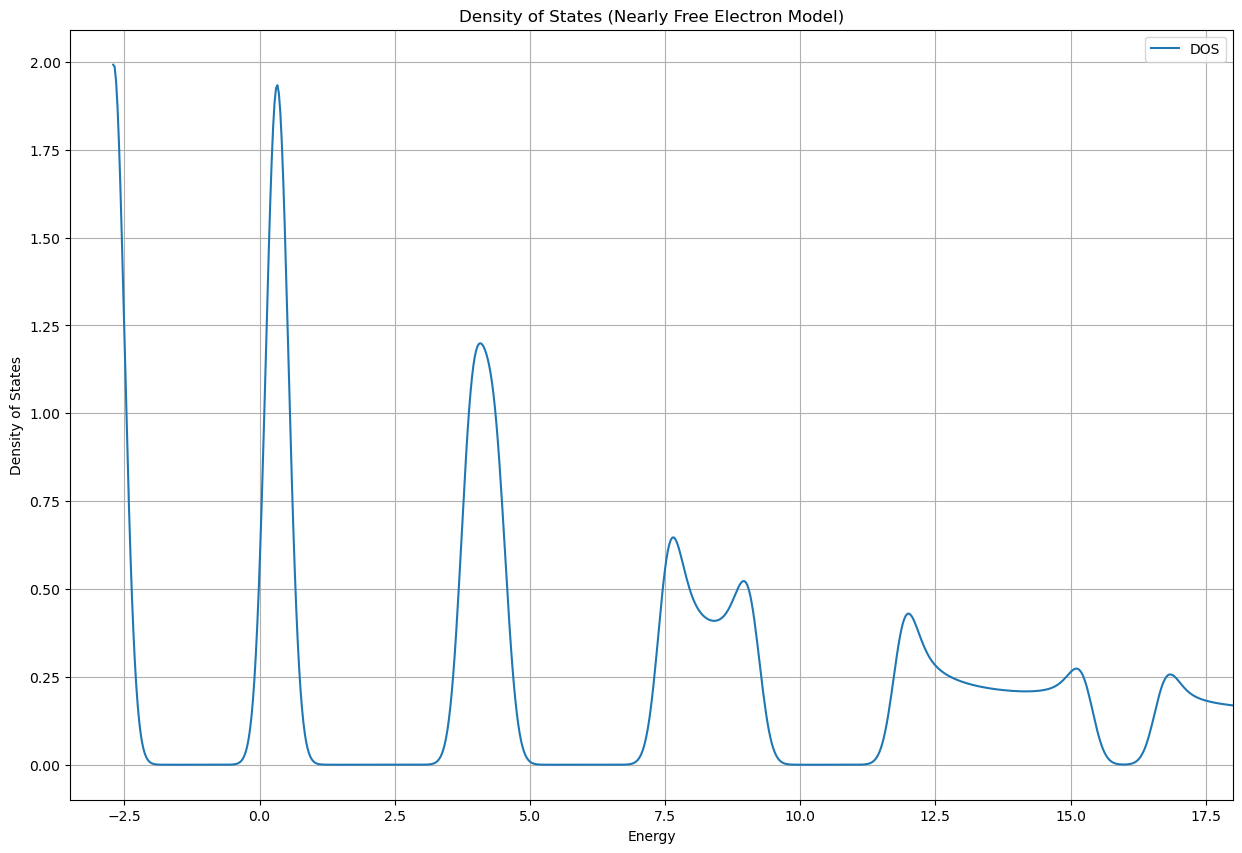

In [269]:
energies = bds.flatten()

E_min = np.min(energies)
E_max = np.max(energies)
E_grid = np.linspace(E_min, E_max, 2000)

eta = 0.2   
DOS = np.zeros_like(E_grid)
for E in energies:
    DOS += np.exp(-(E_grid - E)**2 / (2*eta**2))

DOS /= (np.sqrt(2*np.pi)*eta)
DOS /= len(k_vals)   

plt.figure(figsize=(15,10))
plt.plot(E_grid, DOS, label="DOS")
plt.ylabel("Density of States")
plt.xlabel("Energy")
plt.xlim((-3.5,18))
plt.title("Density of States (Nearly Free Electron Model)")
plt.grid(True)
plt.legend()

A similar trend in density of states is observed with larger band gaps (since a '2A' weighted potential term is added)

### Total energy vs A 

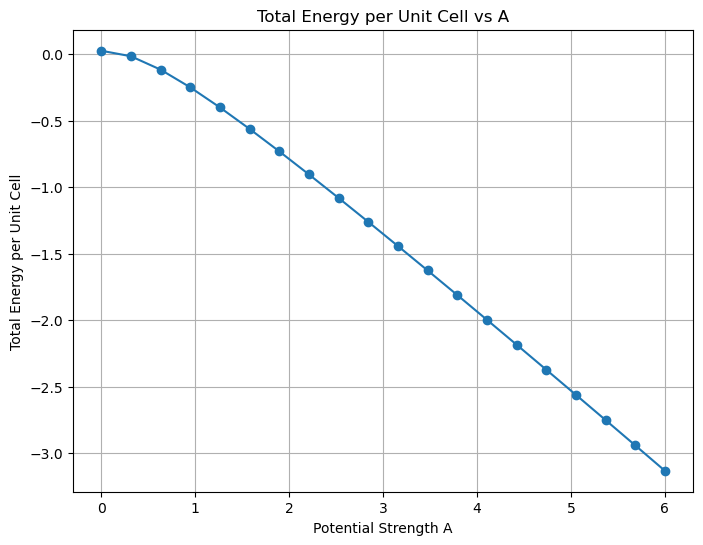

In [270]:
def total_energy_per_cell(A, Nk=1000, M=4):
    
    a = 1.0
    G = np.pi/(2*a)
    
    V1 = A
    V2 = A/2
    V3 = A/4
    V4 = A/6
    
    basis_m = np.arange(-M, M+1)
    k_vals = np.linspace(-np.pi/(2*a), np.pi/(2*a), Nk)
    
    bands = []
    
    for k in k_vals:
        size = len(basis_m)
        H = np.zeros((size, size))
        
        for i, m in enumerate(basis_m):
            H[i, i] = (k + m*G)**2

            if i+1 < size:
                H[i, i+1] = V1
                H[i+1, i] = V1
                
            if i+2 < size:
                H[i, i+2] = V2
                H[i+2, i] = V2

            if i+3 < size:
                H[i, i+3] = V3
                H[i+3, i] = V3

            if i+4 < size:
                H[i, i+4] = V4
                H[i+4, i] = V4
        
        eigvals = np.linalg.eigvalsh(H)
        bands.append(eigvals)
    
    bands = np.array(bands)
    all_energies = bands.flatten()
    all_energies.sort()
    Ne = Nk//2   # 1 electron per unit cell (spin degeneracy = 2)
    occupied = all_energies[:Ne]
    Etot = np.sum(occupied) / Nk
    
    return Etot

A_values = np.linspace(0, 6, 20)
Etot_values = []

for A in A_values:
    Etot = total_energy_per_cell(A, Nk=1000, M=4)
    Etot_values.append(Etot)

plt.figure(figsize=(8,6))

plt.plot(A_values, Etot_values, marker='o')

plt.xlabel("Potential Strength A")
plt.ylabel("Total Energy per Unit Cell")
plt.title("Total Energy per Unit Cell vs A")
plt.grid(True)
plt.show()

As the potential strength $A$ increases, the total energy per unit cell decreases almost linearly.

At $A = 0$, the total energy per unit cell iS highest. This represents the "Free Electron" limit where no lattice potential is felt by the electrons.

## Improved approach for Electronic structure

### Using Poisson's equation in Fourier Basis


The single-particle Hamiltonian becomes:

$H = -\frac{1}{2}\nabla^2 + V_{\text{ext}}(x) + V_p(x)$

The external periodic potential is:


$V_{\text{ext}}(x)=A\cos(Gx)+ \frac{A}{2}\cos(2Gx)+ \frac{A}{3}\cos(3Gx)$

where $G = \pi/a$

Bloch states are expanded as:

$\psi_k(x)=\sum_G c_{k,G} e^{i(k+G)x}$

The charge density is:

$\rho(x)=2\times \sum_{\text{occ}} |\psi_{n,k}(x)|^2$  (2 is due to spin degeneracy)

Fourier components:


$\rho_G=2 \times \sum_{\text{occ},k} \sum_{G'} c^*_{k,G'}c_{k,G'+G}$  (2 is due to spin degeneracy)


Poisson equation in Fourier space:


$V_H(G)=\frac{4\pi}{G^2}\rho(G), \quad G\neq0$

The $G=0$ term is set to zero.

We iteratively:

1. Solve the Schrödinger equation.
2. Compute the density from occupied states.
3. Solve Poisson equation.
4. Update the effective potential.
5. Repeat until convergence.

Iteration 0  Error = 1.7103603523364077
Iteration 1  Error = 0.025527896386870218
Iteration 2  Error = 0.0007539457873584907
Iteration 3  Error = 2.2143997231121117e-05
Iteration 4  Error = 6.505565256323817e-07
Iteration 5  Error = 1.911227306381547e-08
Iteration 6  Error = 5.614890214024374e-10
Converged


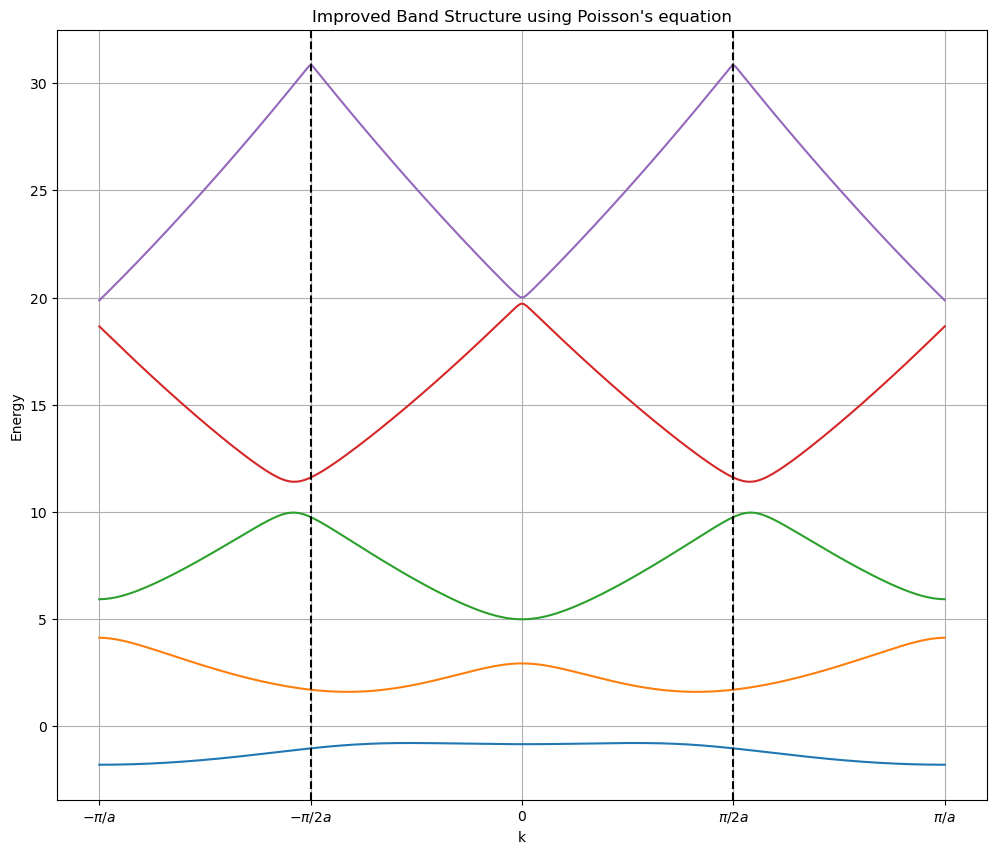

In [271]:
G0 = np.pi/a

M = 4
basis_m = np.arange(-M, M+1)
NG = len(basis_m)
Nk = 300
k_vals = np.linspace(-np.pi/a, np.pi/a, Nk)

A = 3.0
mixing = 1
tol = 1e-9
max_iter = 50

def external_potential_fourier(A):
    Vext = np.zeros(NG)
    for i, m in enumerate(basis_m):
        if abs(m) == 1:
            Vext[i] = A/2
        elif abs(m) == 2:
            Vext[i] = A/4
        elif abs(m) == 3:
            Vext[i] = A/6
    return Vext

def build_hamiltonian(k, Vext, VH):
    H = np.zeros((NG, NG), dtype=complex)
    for i, m in enumerate(basis_m):
        G = m * G0
        # kinetic
        H[i,i] = 0.5*(k + G)**2 + VH[i]
        for j, mp in enumerate(basis_m):
            dG = m - mp
            if abs(dG) == 1:
                H[i,j] += A/2
            if abs(dG) == 2:
                H[i,j] += A/4
            if abs(dG) == 3:
                H[i,j] += A/6
    return H

def compute_density_fourier(eigvecs_all):
    rho_G = np.zeros(NG, dtype=complex)
    for k_index in range(Nk):
        C = eigvecs_all[k_index][:,0]  
        for i in range(NG):
            for j in range(NG):
                dG = basis_m[i] - basis_m[j]
                
                if dG in basis_m:
                    idx = np.where(basis_m == dG)[0][0]
                    rho_G[idx] += np.conj(C[j]) * C[i]
    rho_G /= Nk
    rho_G = rho_G*2
    return rho_G.real

def solve_poisson(rho_G):
    VH = np.zeros(NG)
    for i, m in enumerate(basis_m):
        G = m * G0
        if m != 0:
            VH[i] = 4*np.pi * rho_G[i] / (G**2)
        else:
            VH[i] = 0  
    return VH

Vext = external_potential_fourier(A)
VH = np.zeros(NG)

for iteration in range(max_iter):
    eigvecs_all = []
    eigvals_all = []
    for k in k_vals:
        H = build_hamiltonian(k, Vext, VH)
        eigvals, eigvecs = np.linalg.eigh(H)
        eigvals_all.append(eigvals)
        eigvecs_all.append(eigvecs)
    eigvecs_all = np.array(eigvecs_all)
    rho_new = compute_density_fourier(eigvecs_all)
    VH_new = solve_poisson(rho_new)
    error = np.linalg.norm(VH_new - VH)
    VH = mixing*VH_new + (1-mixing)*VH
    print(f"Iteration {iteration}  Error = {error}")
    
    if error < tol:
        print("Converged")
        break

eigvals_all = np.array(eigvals_all)

plt.figure(figsize=(12,10))

for n in range(5):
    plt.plot(k_vals, eigvals_all[:,n])

plt.axvline(np.pi/(2*a), linestyle='--', color='black')
plt.axvline(-np.pi/(2*a), linestyle='--', color='black')

tp = [-np.pi/a, -np.pi/2*a, 0, np.pi/2*a, np.pi/a]
tl = [r"$-\pi/a$", r"$-\pi/2a$", r"$0$", r"$\pi/2a$", r"$\pi/a$"]

plt.xticks(tp, tl)
plt.xlabel("k")
plt.ylabel("Energy")
plt.title("Improved Band Structure using Poisson's equation")
plt.grid(True)
plt.show()

The band structure got modified. The band gaps change. When we considered these terms in potential we took into account the screening effects due to mucltiple electrons. Hence we obtain an improved estimation of the band structure.